In [1]:
%pip install pandas scikit-learn matplotlib

  Using cached scikit_learn-1.8.0-cp314-cp314-win_amd64.whl.metadata (11 kB)
  Using cached scipy-1.17.1-cp314-cp314-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.8.0-cp314-cp314-win_amd64.whl (8.1 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   ---------------------------------------- 0.3/37.3 MB ? eta -:--:--
   - -------------------------------------- 1.3/37.3 MB 5.2 MB/s eta 0:00:07
   -- ------------------------------------- 2.6/37.3 MB 6.4 MB/s eta 0:00:06
   --- ------------------------------------ 3.4/37.3 MB 5.5 MB/s eta 0:00:07
   ---- ----------------------------------- 4.2/37.3 MB 4.8 MB/s eta 0:00:07
   ----- ---------------------------------- 4.7/37.3 MB 4.6 MB/s eta 0:00:08
   ----- ---------------------------------- 5.5/37.3 MB 4.3 MB/s eta 0:00:08


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot  as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score



In [7]:
data = {
    "Hours_Studied": [1,2,3,4,5,6,7,8,2,5,6,7],
    "Attendance": [50,55,60,65,70,80,90,95,58,72,85,92],
    "Assignments": [1,1,2,2,3,4,5,5,2,3,4,5],
    "Pass": [0,0,0,1,1,1,1,1,0,1,1,1]
}
print(data)
print(type(data))

{'Hours_Studied': [1, 2, 3, 4, 5, 6, 7, 8, 2, 5, 6, 7], 'Attendance': [50, 55, 60, 65, 70, 80, 90, 95, 58, 72, 85, 92], 'Assignments': [1, 1, 2, 2, 3, 4, 5, 5, 2, 3, 4, 5], 'Pass': [0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1]}
<class 'dict'>


In [10]:
df = pd.DataFrame(data)
df

,Hours_Studied,Attendance,Assignments,Pass
0,1,50,1,0
1,2,55,1,0
2,3,60,2,0
3,4,65,2,1
4,5,70,3,1
5,6,80,4,1
6,7,90,5,1
7,8,95,5,1
8,2,58,2,0
9,5,72,3,1


In [21]:
x = df[["Hours_Studied","Attendance","Assignments"]]
y = df["Pass"]#doubt is why not here we use [[]] double brakcet like for x
#print(x)
x


,Hours_Studied,Attendance,Assignments
0,1,50,1
1,2,55,1
2,3,60,2
3,4,65,2
4,5,70,3
5,6,80,4
6,7,90,5
7,8,95,5
8,2,58,2
9,5,72,3


In [22]:
x_train,x_test,y_train,y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state = 42
)
print("Training Data size: ", len(x_train))
print("Testing Data size: ", len(x_test))

Training Data size:  9
Testing Data size:  3


In [23]:
model = DecisionTreeClassifier()
model.fit(x_train,y_train)
print("model Trained successfully")

model Trained successfully


In [33]:
predictions = model.predict(x_test);
print("Predictions:",predictions)
x_test

Predictions: [1 1 0]


,Hours_Studied,Attendance,Assignments
10,6,85,4
9,5,72,3
0,1,50,1


In [ ]:
accuracy = accuracy_score(y_test,predictions)
print("Accuracy:",accuracy)

Accuracy: 1.0


In [36]:
new_student =[[5,75,3]]#Hours_Studies,Attendance,Assignment
result = model.predict(new_student)
if result[0] == 1:
    print("Student will Pass")
else:
    print("Student will Fail")

Student will Pass


c:\Users\samee\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


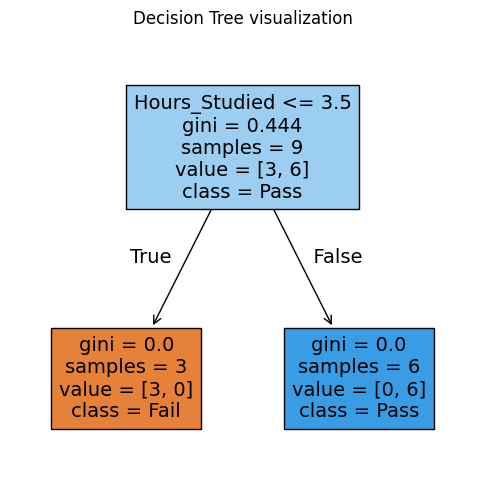

In [41]:
plt.figure(figsize=(6,6))
tree.plot_tree(
    model,
    feature_names=["Hours_Studied","Attendance","Assignments"],
    class_names = ["Fail","Pass"],
    filled = True
)
plt.title("Decision Tree visualization")
plt.show()